In [1]:
import os
import torch
import torch.nn as nn
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import timm
import matplotlib.pyplot as plt
import numpy as np


In [3]:
#Original Path
train_annotation_path = '/kaggle/input/train-150-labels/train_label_150.xlsx'
test_annotation_path = '/kaggle/input/train-150-labels/train_label_150.xlsx'
base_image_folder = '/kaggle/input/train-data-images/All Corek 5K Images'


# Combine train and test sheet, annotation 

In [2]:
#combine
merge_annotation_path = '/kaggle/input/updated-annotation/train_test_label_updated.xlsx'
xls_combined = pd.ExcelFile(merge_annotation_path)
df_combined = pd.read_excel(xls_combined, sheet_name='Merge')
base_image_folder = '/kaggle/input/train-data-images/All Corek 5K Images'

# Compute the average frequency 

In [3]:
# Extract metadata + label columns
df_metadata = df_combined.iloc[:, :2]
df_labels = df_combined.iloc[:, 2:]
# Sum of each label across all rows
label_counts = df_labels.sum()
# Compute average frequency (as float)
average_frequency = label_counts.mean()
print("Average label frequency:", average_frequency)
# Filter labels that exactly match the average frequency (rounded comparison)
labels_with_avg_freq = label_counts[label_counts == average_frequency].index.tolist()

# Step 3: Filter labels >= or close to average (within a tolerance range)
tolerance = 1  # adjust this value if needed
labels_gte_avg = label_counts[label_counts >= (average_frequency - tolerance)]
# Step 4: Count the selected labels
num_selected_labels = len(labels_gte_avg)
# Step 5: Display results
print(f"\nNumber of labels with frequency ≥ or ≈ average: {num_selected_labels}")
print("\nSelected labels and their frequencies:")
for label, freq in labels_gte_avg.items():
    print(f"{label}: {freq}")

Average label frequency: 47.07486631016043

Number of labels with frequency ≥ or ≈ average: 84

Selected labels and their frequencies:
city: 77
mountain: 345
sky: 988
sun: 111
water: 1120
clouds: 280
tree: 947
beach: 195
boats: 170
people: 744
branch: 80
leaf: 148
grass: 497
horizon: 63
hills: 131
waves: 49
birds: 196
bridge: 138
buildings: 462
jet: 166
plane: 224
smoke: 54
bear: 220
polar: 135
snow: 298
ice: 111
head: 73
reflection: 64
ground: 64
forest: 82
river: 52
field: 215
flowers: 296
rocks: 250
close-up: 122
sunset: 83
plants: 144
pool: 88
coral: 98
ocean: 105
sand: 203
reefs: 61
house: 143
coast: 89
cat: 107
tiger: 101
fox: 80
shore: 59
town: 57
road: 51
wall: 111
skyline: 59
window: 87
shops: 63
street: 229
ruins: 119
stone: 232
cars: 151
castle: 55
statue: 117
palace: 60
valley: 133
temple: 104
sculpture: 86
garden: 127
church: 48
park: 57
arch: 61
pillar: 58
tower: 47
horses: 115
petals: 63
frost: 81
nest: 78
deer: 51
mare: 78
foals: 86
train: 105
desert: 66
swimmers: 93
tr

In [3]:
# Step 1: Extract metadata and label columns
df_metadata = df_combined.iloc[:, :2]
df_labels = df_combined.iloc[:, 2:]

# Step 2: Sum of each label across all rows
label_counts = df_labels.sum()

# Step 3: Compute average frequency
average_frequency = label_counts.mean()
print("Average label frequency:", average_frequency)

# Optional: Labels that exactly match average (rounded)
labels_with_avg_freq = label_counts[label_counts == average_frequency].index.tolist()

# Step 4: Filter labels >= or close to average (within tolerance)
tolerance = 1  # you can adjust
labels_gte_avg = label_counts[label_counts >= (average_frequency - tolerance)]

# Step 5: Display results
num_selected_labels = len(labels_gte_avg)
print(f"\nNumber of labels with frequency ≥ or ≈ average: {num_selected_labels}")
print("\nSelected labels and their frequencies:")
for label, freq in labels_gte_avg.items():
    print(f"{label}: {freq}")

# Step 6: Save selected labels and their frequencies to CSV
df_selected = labels_gte_avg.reset_index()
df_selected.columns = ['label', 'frequency']
df_selected.to_csv('/kaggle/working/selected_labels.csv', index=False)

print("\n✅ Saved filtered label frequencies to 'selected_labels.csv'")


Average label frequency: 47.07486631016043

Number of labels with frequency ≥ or ≈ average: 84

Selected labels and their frequencies:
city: 77
mountain: 345
sky: 988
sun: 111
water: 1120
clouds: 280
tree: 947
beach: 195
boats: 170
people: 744
branch: 80
leaf: 148
grass: 497
horizon: 63
hills: 131
waves: 49
birds: 196
bridge: 138
buildings: 462
jet: 166
plane: 224
smoke: 54
bear: 220
polar: 135
snow: 298
ice: 111
head: 73
reflection: 64
ground: 64
forest: 82
river: 52
field: 215
flowers: 296
rocks: 250
close-up: 122
sunset: 83
plants: 144
pool: 88
coral: 98
ocean: 105
sand: 203
reefs: 61
house: 143
coast: 89
cat: 107
tiger: 101
fox: 80
shore: 59
town: 57
road: 51
wall: 111
skyline: 59
window: 87
shops: 63
street: 229
ruins: 119
stone: 232
cars: 151
castle: 55
statue: 117
palace: 60
valley: 133
temple: 104
sculpture: 86
garden: 127
church: 48
park: 57
arch: 61
pillar: 58
tower: 47
horses: 115
petals: 63
frost: 81
nest: 78
deer: 51
mare: 78
foals: 86
train: 105
desert: 66
swimmers: 93
tr

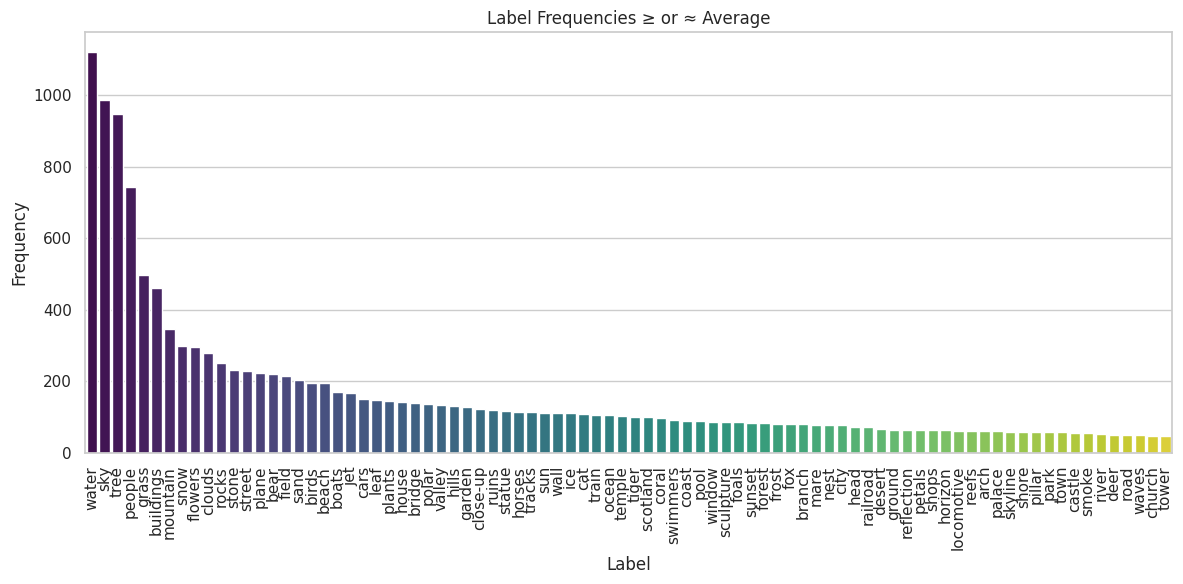

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set figure size and style
plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")

# Sort by frequency (optional)
df_selected_sorted = df_selected.sort_values(by="frequency", ascending=False)

# Plot
sns.barplot(data=df_selected_sorted, x="label", y="frequency", palette="viridis")

# Formatting
plt.xticks(rotation=90)
plt.title("Label Frequencies ≥ or ≈ Average")
plt.xlabel("Label")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()



# Select Exactly N Samples per Label

In [4]:
# Filter to only selected label columns

selected_label_names = labels_gte_avg.index.tolist()
df_selected_labels = df_labels[selected_label_names]
df_selected = pd.concat([df_metadata, df_selected_labels], axis=1)
subset_rows = pd.DataFrame()
for label in selected_label_names:
    label_rows = df_selected[df_selected[label] == 1]
    if len(label_rows) >= 50:
   # if len(label_rows) >= 75:
    #if len(label_rows) >= 100:
    #if len(label_rows) >= 150:
    #if len(label_rows) >= 200:
        sampled_rows = label_rows.sample(n=50, random_state=42)
        #sampled_rows = label_rows.sample(n=75, random_state=42)
        #sampled_rows = label_rows.sample(n=100, random_state=42)
        #sampled_rows = label_rows.sample(n=150, random_state=42)
        #sampled_rows = label_rows.sample(n=200, random_state=42)
        subset_rows = pd.concat([subset_rows, sampled_rows])
subset_rows = subset_rows.drop_duplicates()

# Step 10: Final results
print(f"\nTotal unique images selected: {len(subset_rows)}")
print("\nSample of selected data:")
print(subset_rows.head())
subset_rows.to_csv("subset_50_per_label.csv", index=False)


Total unique images selected: 2904

Sample of selected data:
      Image no    file_name  city  mountain  sky  sun  water  clouds  tree  \
151     148018  148018.jpeg     1         0    0    0      0       0     0   
1855    148008  148008.jpeg     1         0    0    0      1       0     0   
499       1000    1000.jpeg     1         1    1    1      0       0     0   
8         1081    1081.jpeg     1         0    0    1      1       0     0   
1874    148029  148029.jpeg     1         0    1    0      0       0     0   

      beach  ...  deer  mare  foals  train  desert  swimmers  tracks  \
151       0  ...     0     0      0      0       0         0       0   
1855      0  ...     0     0      0      0       0         0       0   
499       0  ...     0     0      0      0       0         0       0   
8         0  ...     0     0      0      0       0         0       0   
1874      0  ...     0     0      0      0       0         0       0   

      locomotive  railroad  scotland

In [45]:
df = pd.read_csv("subset_50_per_label.csv")
print(df.columns)


Index(['Image no', 'file_name', 'city', 'mountain', 'sky', 'sun', 'water',
       'clouds', 'tree', 'beach', 'boats', 'people', 'branch', 'leaf', 'grass',
       'horizon', 'hills', 'waves', 'birds', 'bridge', 'buildings', 'jet',
       'plane', 'smoke', 'bear', 'polar', 'snow', 'ice', 'head', 'reflection',
       'ground', 'forest', 'river', 'field', 'flowers', 'rocks', 'close-up',
       'sunset', 'plants', 'pool', 'coral', 'ocean', 'sand', 'reefs', 'house',
       'coast', 'cat', 'tiger', 'fox', 'shore', 'town', 'road', 'wall',
       'skyline', 'window', 'shops', 'street', 'ruins', 'stone', 'cars',
       'castle', 'statue', 'palace', 'valley', 'temple', 'sculpture', 'garden',
       'church', 'park', 'arch', 'pillar', 'tower', 'horses', 'petals',
       'frost', 'nest', 'deer', 'mare', 'foals', 'train', 'desert', 'swimmers',
       'tracks', 'locomotive', 'railroad', 'scotland'],
      dtype='object')


# Augmenting images

In [5]:
import os
import pandas as pd
import torch
from torchvision import transforms
from PIL import Image
from tqdm import tqdm

# Config
 # folder containing the images
output_dir = 'augmented_images'
augment_factor = 2  # how many times to augment each image
image_size = 224  # resize all images to 224x224

# Load metadata
df = pd.read_csv("subset_50_per_label.csv")

# Define augmentations
augmentation_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor()
])

# Helper to save images
def save_augmented_image(tensor_img, save_path):
    img = transforms.ToPILImage()(tensor_img).convert("RGB")
    img.save(save_path)

# Prepare output folders
os.makedirs(output_dir, exist_ok=True)

# Track new metadata
augmented_rows = []

print("Applying augmentations...")
for _, row in tqdm(df.iterrows(), total=len(df)):
    image_path = os.path.join(base_image_folder, row['file_name'])  # updated from 'filename'
    try:
        image = Image.open(image_path).convert("RGB")
    except:
        continue

    # Save original resized
    base_filename = os.path.splitext(row['file_name'])[0]
    original_out = f"{base_filename}_orig.jpg"
    image_resized = transforms.Resize((image_size, image_size))(image)
    image_resized.save(os.path.join(output_dir, original_out))

    row_copy = row.copy()
    row_copy['file_name'] = original_out
    augmented_rows.append(row_copy)

    # Apply augmentations
    for i in range(augment_factor):
        augmented_img = augmentation_transforms(image)
        aug_filename = f"{base_filename}_aug{i+1}.jpg"
        save_path = os.path.join(output_dir, aug_filename)
        save_augmented_image(augmented_img, save_path)

        row_aug = row.copy()
        row_aug['file_name'] = aug_filename
        augmented_rows.append(row_aug)

# Create final augmented DataFrame
df_augmented = pd.DataFrame(augmented_rows)
df_augmented.to_csv("augmented_subset.csv", index=False)

print(f"\n✅ Augmentation complete! Total images: {len(df_augmented)}")
print(f"Saved in: {output_dir}")



Applying augmentations...


100%|██████████| 2904/2904 [01:07<00:00, 43.15it/s]



✅ Augmentation complete! Total images: 8712
Saved in: augmented_images


In [6]:
pip install iterative-stratification

Note: you may need to restart the kernel to use updated packages.


In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the augmented dataset
df = pd.read_csv("augmented_subset.csv")

# Define your label columns (excluding 'file_name' and any ID columns)
label_columns = df.columns.difference(['file_name', 'Image no'])  # Adjust if more metadata columns exist

# Ensure multilabel binarization is consistent
df_labels = df[label_columns].astype(int)

# Perform stratified split for multilabel using iterative stratification
# Requires: pip install iterative-stratification
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

# Assign split columns
df['split'] = 'unassigned'
mskf = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# First split: Train (70%) and Temp (30%)
train_idx, temp_idx = next(mskf.split(df, df_labels))
df.loc[train_idx, 'split'] = 'train'
df_temp = df.iloc[temp_idx].reset_index(drop=True)

# For validation/test split from remaining 30%
val_test_labels = df_labels.iloc[temp_idx].reset_index(drop=True)
val_idx, test_idx = next(MultilabelStratifiedKFold(n_splits=2, shuffle=True, random_state=42).split(df_temp, val_test_labels))
df_temp.loc[val_idx, 'split'] = 'val'
df_temp.loc[test_idx, 'split'] = 'test'

# Combine back
df_final = pd.concat([df.loc[train_idx], df_temp], ignore_index=True)

# Save splits
df_final[df_final['split'] == 'train'].to_csv("train.csv", index=False)
df_final[df_final['split'] == 'val'].to_csv("val.csv", index=False)
df_final[df_final['split'] == 'test'].to_csv("test.csv", index=False)

print("\n✅ Dataset split complete!")
print(f"Train: {len(df_final[df_final['split'] == 'train'])}")
print(f"Val  : {len(df_final[df_final['split'] == 'val'])}")
print(f"Test : {len(df_final[df_final['split'] == 'test'])}")



✅ Dataset split complete!
Train: 6966
Val  : 879
Test : 867


In [11]:
class MultiLabelImageDataset(Dataset):
    def __init__(self, dataframe, image_dir, label_columns, transform=None):
        self.df = dataframe
        self.image_dir = image_dir
        self.label_columns = label_columns
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = os.path.join(self.image_dir, row['file_name'])
        image = Image.open(image_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        labels = torch.tensor(row[self.label_columns].values.astype('float32'))

        return image, labels


In [12]:
#Read the split CSVs
train_df = pd.read_csv("train.csv")
val_df = pd.read_csv("val.csv")
test_df = pd.read_csv("test.csv")
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
train_dataset = MultiLabelImageDataset(train_df, output_dir, label_columns, transform=train_transform)
val_dataset = MultiLabelImageDataset(val_df, output_dir, label_columns, transform=val_test_transform)
test_dataset = MultiLabelImageDataset(test_df, output_dir, label_columns, transform=val_test_transform)
# Example __getitem__ in MultiLabelImageDataset
def __getitem__(self, idx):
    row = self.df.iloc[idx]
    img_path = os.path.join(self.base_dir, row['file_name'])
    image = Image.open(img_path).convert('RGB')
    if self.transform:
        image = self.transform(image)
    
    labels = row[self.label_columns].values.astype(np.float32)
    return image, torch.tensor(labels)
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)


In [7]:
from sklearn.model_selection import train_test_split

# Load CSV again to simulate pipeline continuity
df_subset = pd.read_csv('/kaggle/working/subset_50_per_label.csv')
label_columns = df_subset.columns[2:].tolist()
# Split into train (70%), val (15%), test (15%)
train_df, temp_df = train_test_split(df_subset, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")


Train: 2032, Val: 436, Test: 436


In [10]:
# Tranform the data augmentation
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])
#Custom Dataset



In [12]:
# Create Dataset & Dataloaders ===
train_dataset = MultiLabelImageDataset(train_df, base_image_folder, label_columns, transform=train_transform)
val_dataset = MultiLabelImageDataset(val_df, base_image_folder, label_columns, transform=val_test_transform)
test_dataset = MultiLabelImageDataset(test_df, base_image_folder, label_columns, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

NameError: name 'train_df' is not defined

# USING SWIN CLASSIFIER

In [10]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.metrics import average_precision_score, f1_score
from tqdm import tqdm
import numpy as np
import timm
class SwinClassifier(nn.Module):
    def __init__(self, num_classes):
        super(SwinClassifier, self).__init__()
        self.backbone = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=0)
        self.classifier = nn.Linear(self.backbone.num_features, num_classes)

    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)

In [53]:
from torchinfo import summary
summary(model, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                                  Output Shape              Param #
SwinClassifier                                          [1, 84]                   --
├─SwinTransformer: 1-1                                  [1, 768]                  --
│    └─PatchEmbed: 2-1                                  [1, 56, 56, 96]           --
│    │    └─Conv2d: 3-1                                 [1, 96, 56, 56]           4,704
│    │    └─LayerNorm: 3-2                              [1, 56, 56, 96]           192
│    └─Sequential: 2-2                                  [1, 7, 7, 768]            --
│    │    └─SwinTransformerStage: 3-3                   [1, 56, 56, 96]           224,694
│    │    └─SwinTransformerStage: 3-4                   [1, 28, 28, 192]          966,252
│    │    └─SwinTransformerStage: 3-5                   [1, 14, 14, 384]          10,955,400
│    │    └─SwinTransformerStage: 3-6                   [1, 7, 7, 768]            15,366,576
│    └─LayerNorm: 2-3         

In [11]:
#device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model, Criterion, Optimizer
model = SwinClassifier(num_classes=len(label_columns)).to(device)
criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

# USINT RESNET+SWIN# 

In [12]:
pip install einops

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [61]:
###Define the Resent50 model +Swin Classifier
import torch
import torch.nn as nn
import torchvision.models as models
from einops import rearrange
import timm
from torchvision.models import resnet50, ResNet50_Weights
from timm.models.swin_transformer import SwinTransformer
# Load pretrained ResNet50 with updated syntax
class ResNetSwinHybrid(nn.Module):
    def __init__(self, num_classes, freeze_resnet=True):
        super(ResNetSwinHybrid, self).__init__()

        # Load ResNet50 with updated weights argument
        resnet = resnet50(weights=ResNet50_Weights.DEFAULT)
        self.resnet = nn.Sequential(*list(resnet.children())[:-2])  # Remove avgpool & fc

       # Freeze some ResNet layers
        for name, param in self.resnet.named_parameters():
            if "layer4" not in name:
                param.requires_grad = False
        
        # Project to match Swin input dimension
        self.feature_proj = nn.Conv2d(2048, 96, kernel_size=1)
        
        # Use a small Transformer Encoder instead of full Swin
        encoder_layer = nn.TransformerEncoderLayer(d_model=96, nhead=4, dim_feedforward=384, dropout=0.1)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)

        # Classifier head
        self.classifier = nn.Sequential(
            nn.LayerNorm(96),
            nn.Linear(96, num_classes)
        )

    def forward(self, x):
        B = x.size(0)
        
        # ResNet feature extraction
        with torch.no_grad():
            x = self.resnet(x)           # [B, 2048, 7, 7]

        x = self.feature_proj(x)         # [B, 96, 7, 7]
        x = rearrange(x, 'b c h w -> b (h w) c')  # [B, 49, 96]

        x = self.transformer(x)          # [B, 49, 96]
        x = x.mean(dim=1)                # [B, 96]
        
        return self.classifier(x)        # [B, num_classes]

In [13]:
##UPDATED RESTNET+SWIN LIKE TRANSFORMER

import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights
class ResNetSwinIntermediateFusion(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        resnet = resnet50(weights=ResNet50_Weights.DEFAULT)

        # Freeze early layers
        self.conv1 = resnet.conv1
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3  # <--- Intermediate to be connected to Swin
        self.layer4 = resnet.layer4

        # Freeze layers up to layer2
        for param in self.conv1.parameters():
            param.requires_grad = False
        for param in self.layer1.parameters():
            param.requires_grad = False
        for param in self.layer2.parameters():
            param.requires_grad = False

        # Project layer3 output to Swin input dim (let's say 96)
        self.feature_proj = nn.Conv2d(1024, 96, kernel_size=1)

        # Transformer block to mimic Swin behavior
        encoder_layer = nn.TransformerEncoderLayer(d_model=96, nhead=4, dim_feedforward=384)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)

        # Classification head
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(
            nn.LayerNorm(96),
            nn.Linear(96, num_classes)
        )

    def forward(self, x):
        # ResNet backbone
        x = self.conv1(x)       # (B, 64, H/2, W/2)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)     # (B, 64, H/4, W/4)

        x = self.layer1(x)      # (B, 256, H/4, W/4)
        x = self.layer2(x)      # (B, 512, H/8, W/8)
        x = self.layer3(x)      # (B, 1024, H/16, W/16)

        # Project features to Swin input size
        x = self.feature_proj(x)        # (B, 96, H/16, W/16)
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)  # (B, N, C) for transformer

        x = self.transformer(x)         # (B, N, C)
        x = x.mean(dim=1)               # Global average

        return self.classifier(x)


# USING RESNET50 only

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet50, ResNet50_Weights

class ResNetOnlyFusion(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # === Load pretrained ResNet-50 ===
        resnet = resnet50(weights=ResNet50_Weights.DEFAULT)

        # === Early ResNet Layers ===
        self.conv1 = resnet.conv1
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4

        # === Feature Reductions ===
        self.reduce_64_to_32 = nn.Conv2d(64, 32, kernel_size=1)
        self.reduce_256_to_48 = nn.Conv2d(256, 48, kernel_size=1)
        self.reduce_512_to_64 = nn.Conv2d(512, 64, kernel_size=1)
        self.reduce_1024_to_96 = nn.Conv2d(1024, 96, kernel_size=1)

        # === Compress concatenated features ===
        self.compress_fused = nn.Conv2d(240, 128, kernel_size=1)

        # === Classification Head ===
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(128, num_classes)
        )

        # Optional: Freeze early layers
        for param in self.conv1.parameters():
            param.requires_grad = False

    def forward(self, x):
        # Initial Layers
        x = self.relu(self.bn1(self.conv1(x)))        # (B, 64, 112, 112)
        x = self.maxpool(x)                           # (B, 64, 56, 56)
        feat0 = self.reduce_64_to_32(x)               # (B, 32, 56, 56)

        x1 = self.layer1(x)                           # (B, 256, 56, 56)
        feat1 = self.reduce_256_to_48(x1)             # (B, 48, 56, 56)

        x2 = self.layer2(x1)                          # (B, 512, 28, 28)
        feat2 = self.reduce_512_to_64(x2)             # (B, 64, 28, 28)
        feat2 = F.interpolate(feat2, size=(56, 56), mode='bilinear', align_corners=False)

        x3 = self.layer3(x2)                          # (B, 1024, 14, 14)
        feat3 = self.reduce_1024_to_96(x3)            # (B, 96, 14, 14)
        feat3 = F.interpolate(feat3, size=(56, 56), mode='bilinear', align_corners=False)

        # Fuse and compress
        fused = torch.cat([feat0, feat1, feat2, feat3], dim=1)  # (B, 240, 56, 56)
        fused = self.compress_fused(fused)                      # (B, 128, 56, 56)

        # Classification
        out = self.classifier(fused)                            # (B, num_classes)
        return out


In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet50, ResNet50_Weights
from timm.models.swin_transformer import swin_tiny_patch4_window7_224


class ResNetSwinFusion(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # === Load pretrained ResNet-50 ===
        resnet = resnet50(weights=ResNet50_Weights.DEFAULT)

        # === Early ResNet Layers ===
        self.conv1 = resnet.conv1  # (B, 64, 112, 112)
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool  # (B, 64, 56, 56)
        self.layer1 = resnet.layer1    # (B, 256, 56, 56)
        self.layer2 = resnet.layer2    # (B, 512, 28, 28)

        # === PROJECT INTERMEDIATE FEATURES TO SWIN DIM ===
        self.reduce_64_to_32 = nn.Conv2d(64, 32, kernel_size=1)    # Optional: conv1 output (112x112 → 56x56)
        self.reduce_256_to_48 = nn.Conv2d(256, 48, kernel_size=1)  # layer1 output
        self.reduce_512_to_96 = nn.Conv2d(512, 96, kernel_size=1)  # layer2 output → match Swin

        # === Swin Transformer Tiny ===
        self.swin = swin_tiny_patch4_window7_224(pretrained=True)
        self.swin.patch_embed = nn.Identity()
        self.swin.pos_drop = nn.Identity()

        # === Classification Head ===
        self.head = nn.Sequential(
            nn.LayerNorm(768),
            nn.Linear(768, num_classes)
        )

        # Optionally freeze early ResNet layers
        for param in self.conv1.parameters():
            param.requires_grad = False

    def forward(self, x):
        # === ResNet stages ===
        x = self.relu(self.bn1(self.conv1(x)))     # (B, 64, 112, 112)
        x = self.maxpool(x)                        # (B, 64, 56, 56)
        early_feat = self.reduce_64_to_32(x)       # (B, 32, 56, 56) ← could be used for skip fusion later

        x1 = self.layer1(x)                        # (B, 256, 56, 56)
        feat1 = self.reduce_256_to_48(x1)          # (B, 48, 56, 56)

        x2 = self.layer2(x1)                       # (B, 512, 28, 28)
        feat2 = self.reduce_512_to_96(x2)          # (B, 96, 28, 28)
        feat2 = F.interpolate(feat2, size=(56, 56), mode='bilinear', align_corners=False)  # Match Swin input

        # === Merge Intermediate Features ===
        fused = torch.cat([early_feat, feat1, feat2], dim=1)  # (B, 32+48+96=176, 56, 56)
        fused = nn.Conv2d(176, 96, kernel_size=1)(fused)      # Compress to (B, 96, 56, 56)

        # === Prepare for Swin ===
        x = fused.permute(0, 2, 3, 1)                         # (B, 56, 56, 96)
        x = self.swin.forward_features(x)                    # (B, 7, 7, 768)
        x = x.mean(dim=(1, 2))                                # Global avg pooling

        out = self.head(x)                                   # Final class logits
        return out


# USING RESNET+SWIN FINAL VERSION

In [15]:

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet50, ResNet50_Weights
from timm.models.swin_transformer import swin_tiny_patch4_window7_224

class ResNetSwinFusion(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # === Load pretrained ResNet-50 ===
        resnet = resnet50(weights=ResNet50_Weights.DEFAULT)

        # === Early ResNet Layers ===
        self.conv1 = resnet.conv1
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2

        # === Intermediate Feature Projection ===
        self.reduce_64_to_32 = nn.Conv2d(64, 32, kernel_size=1)
        self.reduce_256_to_48 = nn.Conv2d(256, 48, kernel_size=1)
        self.reduce_512_to_96 = nn.Conv2d(512, 96, kernel_size=1)

        # === Compress concatenated features ===
        self.compress_fused = nn.Conv2d(176, 96, kernel_size=1)

        # === Swin Transformer Tiny ===
        self.swin = swin_tiny_patch4_window7_224(pretrained=True)
        self.swin.patch_embed = nn.Identity()
        self.swin.pos_drop = nn.Identity()

        # === Classification Head ===
        self.head = nn.Sequential(
            nn.LayerNorm(768),
            nn.Linear(768, num_classes)
        )

        # === Freeze Early ResNet if needed ===
        for param in self.conv1.parameters():
            param.requires_grad = False

    def forward(self, x):
        # ResNet early stages
        x = self.relu(self.bn1(self.conv1(x)))     # (B, 64, 112, 112)
        x = self.maxpool(x)                        # (B, 64, 56, 56)
        early_feat = self.reduce_64_to_32(x)       # (B, 32, 56, 56)

        x1 = self.layer1(x)                        # (B, 256, 56, 56)
        feat1 = self.reduce_256_to_48(x1)          # (B, 48, 56, 56)

        x2 = self.layer2(x1)                       # (B, 512, 28, 28)
        feat2 = self.reduce_512_to_96(x2)          # (B, 96, 28, 28)
        feat2 = F.interpolate(feat2, size=(56, 56), mode='bilinear', align_corners=False)

        # Merge and compress
        fused = torch.cat([early_feat, feat1, feat2], dim=1)  # (B, 176, 56, 56)
        fused = self.compress_fused(fused)                    # (B, 96, 56, 56)

        # Swin expects (B, H, W, C)
        x = fused.permute(0, 2, 3, 1)                         # (B, 56, 56, 96)
        x = self.swin.forward_features(x)                     # (B, 7, 7, 768)
        x = x.mean(dim=(1, 2))                                # Global average pooling

        out = self.head(x)
        return out


# COMPILING THE MODEL

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ResNetOnlyFusion(num_classes=len(label_columns)).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 180MB/s]


In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ResNetSwinIntermediateFusion(num_classes=len(label_columns)).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 157MB/s] 
/opt/conda/lib/python3.10/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ResNetSwinFusion(num_classes=len(label_columns)).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 185MB/s]


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

# Custom CNN + Swin Transformer Model Function

In [58]:
import torch
import torch.nn as nn
from timm import create_model

class CustomCNN(nn.Module):
    def __init__(self):
        super(CustomCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.LeakyReLU(0.1),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.LeakyReLU(0.1),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),
            nn.Dropout(0.5),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.LeakyReLU(0.1),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.LeakyReLU(0.1),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),
            nn.Dropout(0.3),
        )
    
    def forward(self, x):
        return self.features(x)

class CNN_Swin_Hybrid(nn.Module):
    def __init__(self, num_classes):
        super(CNN_Swin_Hybrid, self).__init__()
        self.cnn = CustomCNN()
        self.swin = create_model("swin_tiny_patch4_window7_224", pretrained=True, num_classes=num_classes)
        
        # Optional: if cnn output size ≠ 3-channel input, add 1x1 conv to reshape channels
        self.channel_adapter = nn.Conv2d(64, 3, kernel_size=1)

    def forward(self, x):
        x = self.cnn(x)  # Output: (B, 64, H/4, W/4)
        x = self.channel_adapter(x)  # Make it (B, 3, H/4, W/4) for Swin
        x = nn.functional.interpolate(x, size=(224, 224))  # Resize for Swin input
        return self.swin(x)


In [32]:
import torch.optim as optim
# Automatically select GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN_Swin_Hybrid(num_classes=len(label_columns)).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)


In [26]:
# ============ Metric  ============

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
train_maps, val_maps = [], []
train_f1s, val_f1s = [], []
num_epochs = 20  

# Early Stopping Parameters
best_val_map = -np.inf
patience = 5
patience_counter = 0
best_model_state = None
# ============ Training Loop ============
for epoch in range(num_epochs):
    model.train()
    total_loss, total_correct, total_samples = 0, 0, 0
    all_train_preds, all_train_labels = [], []

    for images, labels in tqdm(train_loader, desc=f"[Train] Epoch {epoch+1}/{num_epochs}"):
        images, labels = images.to(device), labels.to(device).float()

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = (outputs.sigmoid() > 0.5).float()
        total_correct += (preds == labels).sum().item()
        total_samples += labels.numel()

        all_train_preds.append(preds.cpu().numpy())
        all_train_labels.append(labels.cpu().numpy())

    # Compute Metrics
    avg_loss = total_loss / len(train_loader)
    acc = total_correct / total_samples
    train_preds = np.vstack(all_train_preds)
    train_labels = np.vstack(all_train_labels)
    train_map = average_precision_score(train_labels, train_preds, average='macro')
    train_f1 = f1_score(train_labels, train_preds, average='macro', zero_division=0)

    # Store Metrics
    train_losses.append(avg_loss)
    train_accuracies.append(acc)
    train_maps.append(train_map)
    train_f1s.append(train_f1)

    print(f"[Train] Epoch {epoch+1}: Loss={avg_loss:.4f} | Acc={acc:.4f} | mAP={train_map:.4f} | F1={train_f1:.4f}")

[Train] Epoch 1/20: 100%|██████████| 67/67 [00:10<00:00,  6.17it/s]


[Train] Epoch 1: Loss=0.1258 | Acc=0.9645 | mAP=0.0410 | F1=0.0106


[Train] Epoch 2/20: 100%|██████████| 67/67 [00:10<00:00,  6.33it/s]


[Train] Epoch 2: Loss=0.1207 | Acc=0.9647 | mAP=0.0423 | F1=0.0135


[Train] Epoch 3/20: 100%|██████████| 67/67 [00:10<00:00,  6.36it/s]


...

[Train] Epoch 18: Loss=0.0757 | Acc=0.9750 | mAP=0.2366 | F1=0.2981


[Train] Epoch 19/20: 100%|██████████| 67/67 [00:10<00:00,  6.52it/s]


[Train] Epoch 19: Loss=0.0738 | Acc=0.9759 | mAP=0.2601 | F1=0.3229


[Train] Epoch 20/20: 100%|██████████| 67/67 [00:10<00:00,  6.49it/s]


[Train] Epoch 20: Loss=0.0721 | Acc=0.9764 | mAP=0.2731 | F1=0.3434


In [15]:
from tqdm import tqdm
from sklearn.metrics import average_precision_score, f1_score, accuracy_score
import numpy as np
import torch

num_epochs = 30
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
train_maps, val_maps = [], []
train_f1s, val_f1s = [], []

best_val_map = -np.inf
best_train_map = -np.inf
patience = 5
patience_counter = 0
best_model_state = None
best_val_acc = 0
best_val_f1 = 0
best_epoch = 0

best_train_acc = 0
best_train_f1 = 0
best_train_epoch = 0

for epoch in range(num_epochs):
    # -------- Training --------
    model.train()
    total_loss = 0
    total_correct = 0
    total_samples = 0
    all_train_preds = []
    all_train_labels = []

    for images, labels in tqdm(train_loader, desc=f"[Train] Epoch {epoch+1}/{num_epochs}"):
        images = images.to(device)
        labels = labels.to(device).float()

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = (outputs.sigmoid() > 0.5).float()
        total_correct += (preds == labels).sum().item()
        total_samples += labels.numel()

        all_train_preds.append(preds.cpu().numpy())
        all_train_labels.append(labels.cpu().numpy())

    # Compute training metrics
    avg_loss = total_loss / len(train_loader)
    acc = total_correct / total_samples
    train_preds = np.vstack(all_train_preds)
    train_labels = np.vstack(all_train_labels)
    train_map = average_precision_score(train_labels, train_preds, average='macro')
    train_f1 = f1_score(train_labels, train_preds, average='macro', zero_division=0)

    train_losses.append(avg_loss)
    train_accuracies.append(acc)
    train_maps.append(train_map)
    train_f1s.append(train_f1)

    print(f"[Train] Epoch {epoch+1}: Loss={avg_loss:.4f} | Acc={acc:.4f} | mAP={train_map:.4f} | F1={train_f1:.4f}")

    # Save best training stats
    if train_map > best_train_map:
        best_train_map = train_map
        best_train_acc = acc
        best_train_f1 = train_f1
        best_train_epoch = epoch + 1

    # -------- Validation --------
    model.eval()
    val_loss = 0
    val_correct = 0
    val_samples = 0
    all_val_preds = []
    all_val_labels = []

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"[Valid] Epoch {epoch+1}/{num_epochs}"):
            images = images.to(device)
            labels = labels.to(device).float()

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            preds = (outputs.sigmoid() > 0.3).float()
            val_correct += (preds == labels).sum().item()
            val_samples += labels.numel()

            all_val_preds.append(preds.cpu().numpy())
            all_val_labels.append(labels.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_acc = val_correct / val_samples
    val_preds = np.vstack(all_val_preds)
    val_labels = np.vstack(all_val_labels)
    val_map = average_precision_score(val_labels, val_preds, average='macro')
    val_f1 = f1_score(val_labels, val_preds, average='macro', zero_division=0)

    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)
    val_maps.append(val_map)
    val_f1s.append(val_f1)

    print(f"[Val]   Epoch {epoch+1}: Loss={avg_val_loss:.4f} | Acc={val_acc:.4f} | mAP={val_map:.4f} | F1={val_f1:.4f}")

    # -------- Early Stopping Check --------
    if val_map > best_val_map:
        best_val_map = val_map
        best_val_acc = val_acc
        best_val_f1 = val_f1
        best_epoch = epoch + 1
        best_model_state = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"--> No improvement. Patience: {patience_counter}/{patience}")

    if patience_counter >= patience:
        print("Early stopping triggered.")
        break

# ========= Final Performance Summary =========
print("\n========== Best Validation Performance ==========")
print(f"Epoch        : {best_epoch}")
print(f"Best mAP     : {best_val_map:.4f}")
print(f"Best Accuracy: {best_val_acc:.4f}")
print(f"Best F1-Score: {best_val_f1:.4f}")

print("\n========== Best Training Performance ==========")
print(f"Epoch        : {best_train_epoch}")
print(f"Best mAP     : {best_train_map:.4f}")
print(f"Best Accuracy: {best_train_acc:.4f}")
print(f"Best F1-Score: {best_train_f1:.4f}")


[Train] Epoch 1/30: 100%|██████████| 218/218 [00:36<00:00,  5.91it/s]


[Train] Epoch 1: Loss=0.1886 | Acc=0.9412 | mAP=0.0380 | F1=0.0234


[Valid] Epoch 1/30: 100%|██████████| 28/28 [00:02<00:00, 13.36it/s]


[Val]   Epoch 1: Loss=0.1199 | Acc=0.9649 | mAP=0.0758 | F1=0.0853


[Train] Epoch 2/30: 100%|██████████| 218/218 [00:35<00:00,  6.13it/s]


...

[Val]   Epoch 29: Loss=0.0213 | Acc=0.9923 | mAP=0.7857 | F1=0.8757


[Train] Epoch 30/30: 100%|██████████| 218/218 [00:35<00:00,  6.14it/s]


[Train] Epoch 30: Loss=0.0080 | Acc=0.9975 | mAP=0.9166 | F1=0.9554


[Valid] Epoch 30/30: 100%|██████████| 28/28 [00:02<00:00, 13.89it/s]


[Val]   Epoch 30: Loss=0.0225 | Acc=0.9924 | mAP=0.7995 | F1=0.8866

========== Best Validation Performance ==========
Epoch        : 30
Best mAP     : 0.7995
Best Accuracy: 0.9924
Best F1-Score: 0.8866

========== Best Training Performance ==========
Epoch        : 30
Best mAP     : 0.9166
Best Accuracy: 0.9975
Best F1-Score: 0.9554


In [ ]:
aaaaaaaa

In [13]:
# ============ Metric  ============

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
train_maps, val_maps = [], []
train_f1s, val_f1s = [], []
num_epochs = 20  

# Early Stopping Parameters
best_val_map = -np.inf
patience = 5
patience_counter = 0
best_model_state = None
# ============ Training Loop ============
for epoch in range(num_epochs):
    model.train()
    total_loss, total_correct, total_samples = 0, 0, 0
    all_train_preds, all_train_labels = [], []

    for images, labels in tqdm(train_loader, desc=f"[Train] Epoch {epoch+1}/{num_epochs}"):
        images, labels = images.to(device), labels.to(device).float()

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = (outputs.sigmoid() > 0.5).float()
        total_correct += (preds == labels).sum().item()
        total_samples += labels.numel()

        all_train_preds.append(preds.cpu().numpy())
        all_train_labels.append(labels.cpu().numpy())

    # Compute Metrics
    avg_loss = total_loss / len(train_loader)
    acc = total_correct / total_samples
    train_preds = np.vstack(all_train_preds)
    train_labels = np.vstack(all_train_labels)
    train_map = average_precision_score(train_labels, train_preds, average='macro')
    train_f1 = f1_score(train_labels, train_preds, average='macro', zero_division=0)

    # Store Metrics
    train_losses.append(avg_loss)
    train_accuracies.append(acc)
    train_maps.append(train_map)
    train_f1s.append(train_f1)

 #   print(f"[Train] Epoch {epoch+1}: Loss={avg_loss:.4f} | Acc={acc:.4f} | mAP={train_map:.4f} | F1={train_f1:.4f}")

[Train] Epoch 1/20: 100%|██████████| 64/64 [00:31<00:00,  2.01it/s]


[Train] Epoch 1: Loss=0.1623 | Acc=0.9609 | mAP=0.0364 | F1=0.0029


[Train] Epoch 2/20: 100%|██████████| 64/64 [00:22<00:00,  2.91it/s]


[Train] Epoch 2: Loss=0.1372 | Acc=0.9635 | mAP=0.0382 | F1=0.0072


[Train] Epoch 3/20: 100%|██████████| 64/64 [00:21<00:00,  2.94it/s]


...

[Train] Epoch 18: Loss=0.0084 | Acc=0.9984 | mAP=0.9504 | F1=0.9736


[Train] Epoch 19/20: 100%|██████████| 64/64 [00:22<00:00,  2.88it/s]


[Train] Epoch 19: Loss=0.0075 | Acc=0.9986 | mAP=0.9574 | F1=0.9775


[Train] Epoch 20/20: 100%|██████████| 64/64 [00:22<00:00,  2.88it/s]


[Train] Epoch 20: Loss=0.0066 | Acc=0.9988 | mAP=0.9638 | F1=0.9809


In [16]:
# -------- Testing --------
model.eval()
test_loss = 0
test_correct = 0
test_samples = 0
all_test_preds = []
all_test_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="[Test]"):
        images = images.to(device)
        labels = labels.to(device).float()

        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item()
        preds = (outputs.sigmoid() > 0.5).float()
        test_correct += (preds == labels).sum().item()
        test_samples += labels.numel()

        all_test_preds.append(preds.cpu().numpy())
        all_test_labels.append(labels.cpu().numpy())

test_preds = np.vstack(all_test_preds)
test_labels = np.vstack(all_test_labels)

test_acc = test_correct / test_samples
test_map = average_precision_score(test_labels, test_preds, average='macro')
test_f1 = f1_score(test_labels, test_preds, average='macro', zero_division=0)

print(f"[Test] Loss: {test_loss / len(test_loader):.4f} | Acc: {test_acc:.4f} | mAP: {test_map:.4f} | F1: {test_f1:.4f}")

[Test]: 100%|██████████| 28/28 [00:02<00:00, 13.50it/s]


[Test] Loss: 0.0238 | Acc: 0.9929 | mAP: 0.8023 | F1: 0.8873


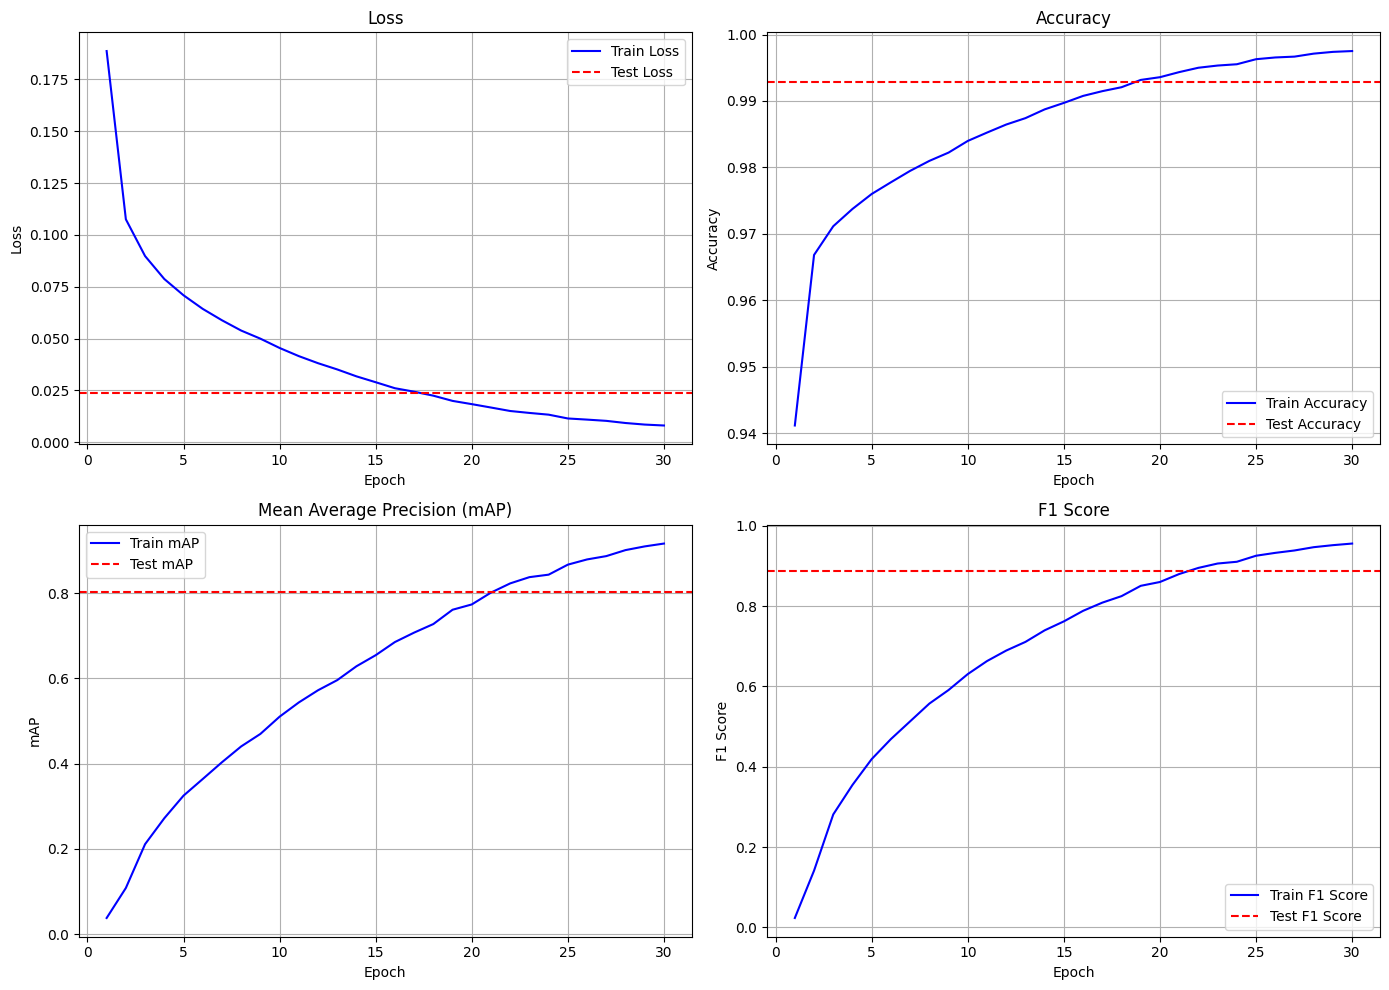

In [17]:
epochs = list(range(1, len(train_losses) + 1))

plt.figure(figsize=(14, 10))

# -------- Loss --------
plt.subplot(2, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss', color='blue')
plt.axhline(y=test_loss / len(test_loader), color='red', linestyle='--', label='Test Loss')
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# -------- Accuracy --------
plt.subplot(2, 2, 2)
plt.plot(epochs, train_accuracies, label='Train Accuracy', color='blue')
plt.axhline(y=test_acc, color='red', linestyle='--', label='Test Accuracy')
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# -------- mAP --------
plt.subplot(2, 2, 3)
plt.plot(epochs, train_maps, label='Train mAP', color='blue')
plt.axhline(y=test_map, color='red', linestyle='--', label='Test mAP')
plt.title("Mean Average Precision (mAP)")
plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.legend()
plt.grid(True)

# -------- F1 Score --------
plt.subplot(2, 2, 4)
plt.plot(epochs, train_f1s, label='Train F1 Score', color='blue')
plt.axhline(y=test_f1, color='red', linestyle='--', label='Test F1 Score')
plt.title("F1 Score")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Visualization of the test sample images truth + predicted

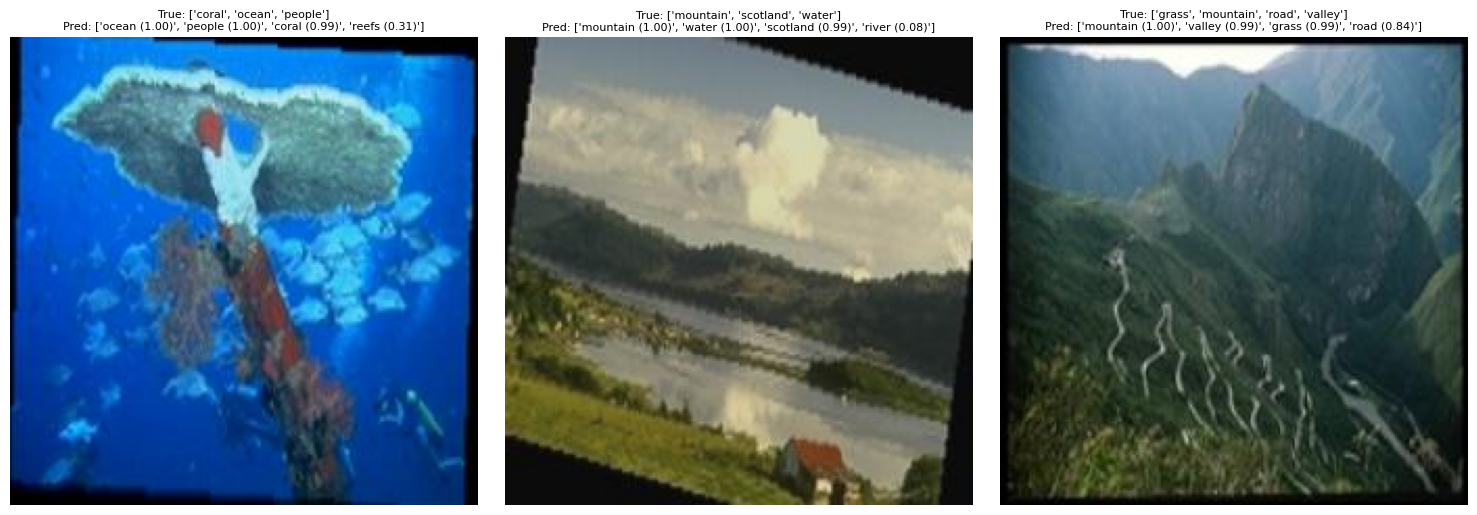

In [18]:
import random
import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision import transforms

# Inverse normalization (ImageNet stats)
inv_normalize = transforms.Normalize(
    mean=[-m/s for m, s in zip([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])],
    std=[1/s for s in [0.229, 0.224, 0.225]]
)

# Mapping from index to label
idx_to_label = {i: label for i, label in enumerate(label_columns)}

# Convert full test dataset to a list
test_samples = list(test_dataset)
num_to_show = 3
top_k = 4

# Randomly select N samples
random_samples = random.sample(test_samples, num_to_show)

plt.figure(figsize=(15, 10))
model.eval()

for i, (image, true_labels) in enumerate(random_samples):
    # Prepare image
    image_input = image.unsqueeze(0).to(device)
    true_labels = true_labels.numpy()

    with torch.no_grad():
        outputs = model(image_input)
        probs = outputs.sigmoid().cpu().squeeze()

    # Get top-k predicted labels and scores
    topk_probs, topk_indices = torch.topk(probs, top_k)
    ranked_preds = [f"{idx_to_label[idx.item()]} ({topk_probs[j].item():.2f})"
                    for j, idx in enumerate(topk_indices)]

    # Get ground truth label names
    true_lbls = [idx_to_label[i] for i in range(len(true_labels)) if true_labels[i] == 1]

    # Convert image to display format
    img_disp = inv_normalize(image).permute(1, 2, 0).numpy()
    img_disp = np.clip(img_disp, 0, 1)

    # Plot
    plt.subplot(2, 3, i + 1)
    plt.imshow(img_disp)
    plt.axis('off')
    plt.title(f"True: {true_lbls}\nPred: {ranked_preds}", fontsize=8)

plt.tight_layout()
plt.show()


In [19]:
from sklearn.metrics import classification_report

# Classification report
report = classification_report(
    test_labels,
    (test_preds > 0.5).astype(int),
    target_names=label_columns,
    zero_division=0
)

print("Classification Report:\n")
print(report)


Classification Report:

              precision    recall  f1-score   support

        arch       1.00      0.81      0.90        16
       beach       1.00      0.81      0.89        31
        bear       0.97      1.00      0.99        38
       birds       0.97      1.00      0.99        34
       boats       1.00      0.85      0.92        33
      branch       0.83      0.75      0.79        20
      bridge       1.00      0.86      0.93        29
   buildings       0.94      0.83      0.88        78
        cars       0.97      0.97      0.97        31
      castle       0.85      0.69      0.76        16
         cat       0.96      1.00      0.98        25
      church       0.80      0.57      0.67         7
        city       1.00      0.78      0.88        18
    close-up       1.00      0.80      0.89        25
      clouds       0.90      0.88      0.89        50
       coast       0.86      0.90      0.88        20
       coral       1.00      1.00      1.00        23
   

In [20]:
pip install torchcam


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


 # === Precision@k ===

In [ ]:
import random
import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision import transforms

# === Inverse normalization (for ImageNet pretrained models) ===
inv_normalize = transforms.Normalize(
    mean=[-m/s for m, s in zip([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])],
    std=[1/s for s in [0.229, 0.224, 0.225]]
)

# === Mapping from index to label ===
idx_to_label = {i: label for i, label in enumerate(label_columns)}

# === Visualize N random samples from the test dataset ===
test_samples = list(test_dataset)
num_to_show = 3
top_k = 4  # Set your desired k for top-k predictions

random_samples = random.sample(test_samples, num_to_show)

plt.figure(figsize=(15, 10))
model.eval()

for i, (image, true_labels) in enumerate(random_samples):
    image_input = image.unsqueeze(0).to(device)
    true_labels = true_labels.numpy()

    with torch.no_grad():
        outputs = model(image_input)
        probs = outputs.sigmoid().cpu().squeeze()

    # === Top-k predicted labels and scores ===
    topk_probs, topk_indices = torch.topk(probs, top_k)
    ranked_preds = [f"{idx_to_label[idx.item()]} ({topk_probs[j].item():.2f})"
                    for j, idx in enumerate(topk_indices)]

    # === Ground truth label names ===
    true_lbls = [idx_to_label[i] for i in range(len(true_labels)) if true_labels[i] == 1]

    # === Precision@k ===
    true_indices = set(np.where(true_labels == 1)[0])
    predicted_topk = set(topk_indices.cpu().numpy())
    correct_preds = predicted_topk.intersection(true_indices)
    precision_at_k = len(correct_preds) / top_k

    # === Convert image to display format ===
    img_disp = inv_normalize(image).permute(1, 2, 0).numpy()
    img_disp = np.clip(img_disp, 0, 1)

    # === Plot ===
    plt.subplot(2, 3, i + 1)
    plt.imshow(img_disp)
    plt.axis('off')
    plt.title(f"True: {true_lbls}\nPred: {ranked_preds}\nPrecision@{top_k}: {precision_at_k:.2f}", fontsize=8)

plt.tight_layout()
plt.show()

# === Compute Average Precision@k over the entire test set ===
total_precision = 0
num_samples = 0
top_k = 3  # You can vary this to Precision@1, @3, @5, etc.

model.eval()
for image, true_labels in test_dataset:
    image_input = image.unsqueeze(0).to(device)
    true_labels = true_labels.numpy()

    with torch.no_grad():
        outputs = model(image_input)
        probs = outputs.sigmoid().cpu().squeeze()

    topk_probs, topk_indices = torch.topk(probs, top_k)

    true_indices = set(np.where(true_labels == 1)[0])
    predicted_topk = set(topk_indices.cpu().numpy())

    correct_preds = predicted_topk.intersection(true_indices)
    precision_at_k = len(correct_preds) / top_k

    total_precision += precision_at_k
    num_samples += 1

average_precision_at_k = total_precision / num_samples
print(f"\n🔎 Average Precision@{top_k} over test set: {average_precision_at_k:.4f}")


In [40]:
#USING THE HYBRID 
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
import torch
import random

# Mean and std used in your transforms.Normalize
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

inv_normalize = transforms.Normalize(
    mean=[-m/s for m, s in zip(mean, std)],
    std=[1/s for s in std]
)

# Setup GradCAM
target_layer = model.feature_proj
cam = GradCAM(model=model, target_layers=[target_layer], reshape_transform=None)

model.eval()
model.to(device)

num_to_show = 3
top_k = 5

fig, axs = plt.subplots(3, num_to_show, figsize=(5 * num_to_show, 10))
test_samples = list(test_dataset)
random_samples = random.sample(test_samples, num_to_show)

for i, (image, true_labels) in enumerate(random_samples):
    input_tensor = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.sigmoid(output).cpu().squeeze()

    topk_probs, topk_indices = torch.topk(probs, top_k)
    predicted_labels = [f"{label_columns[idx]} ({topk_probs[j]:.2f})" for j, idx in enumerate(topk_indices)]

    target_class = topk_indices[0].item()
    grayscale_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(target_class)])
    grayscale_cam = grayscale_cam[0, :]

    inv_image = inv_normalize(image).permute(1, 2, 0).cpu().numpy()
    inv_image = np.clip(inv_image, 0, 1)

    cam_image = show_cam_on_image(inv_image, grayscale_cam, use_rgb=True)

    true_label_names = [label_columns[j] for j in range(len(true_labels)) if true_labels[j] == 1]

    axs[0, i].imshow(inv_image)
    axs[0, i].axis("off")
    axs[0, i].set_title("True:\n" + "\n".join(true_label_names), fontsize=8)

    axs[1, i].imshow(inv_image)
    axs[1, i].axis("off")
    axs[1, i].set_title("Pred:\n" + "\n".join(predicted_labels), fontsize=8)

    axs[2, i].imshow(cam_image)
    axs[2, i].axis("off")
    axs[2, i].set_title("Grad-CAM", fontsize=8)

plt.tight_layout()
plt.show()


ModuleNotFoundError: No module named 'pytorch_grad_cam'

GradCAM Visualization of the test sample images truth + predicted

In [52]:
pip install grad-cam

Note: you may need to restart the kernel to use updated packages.


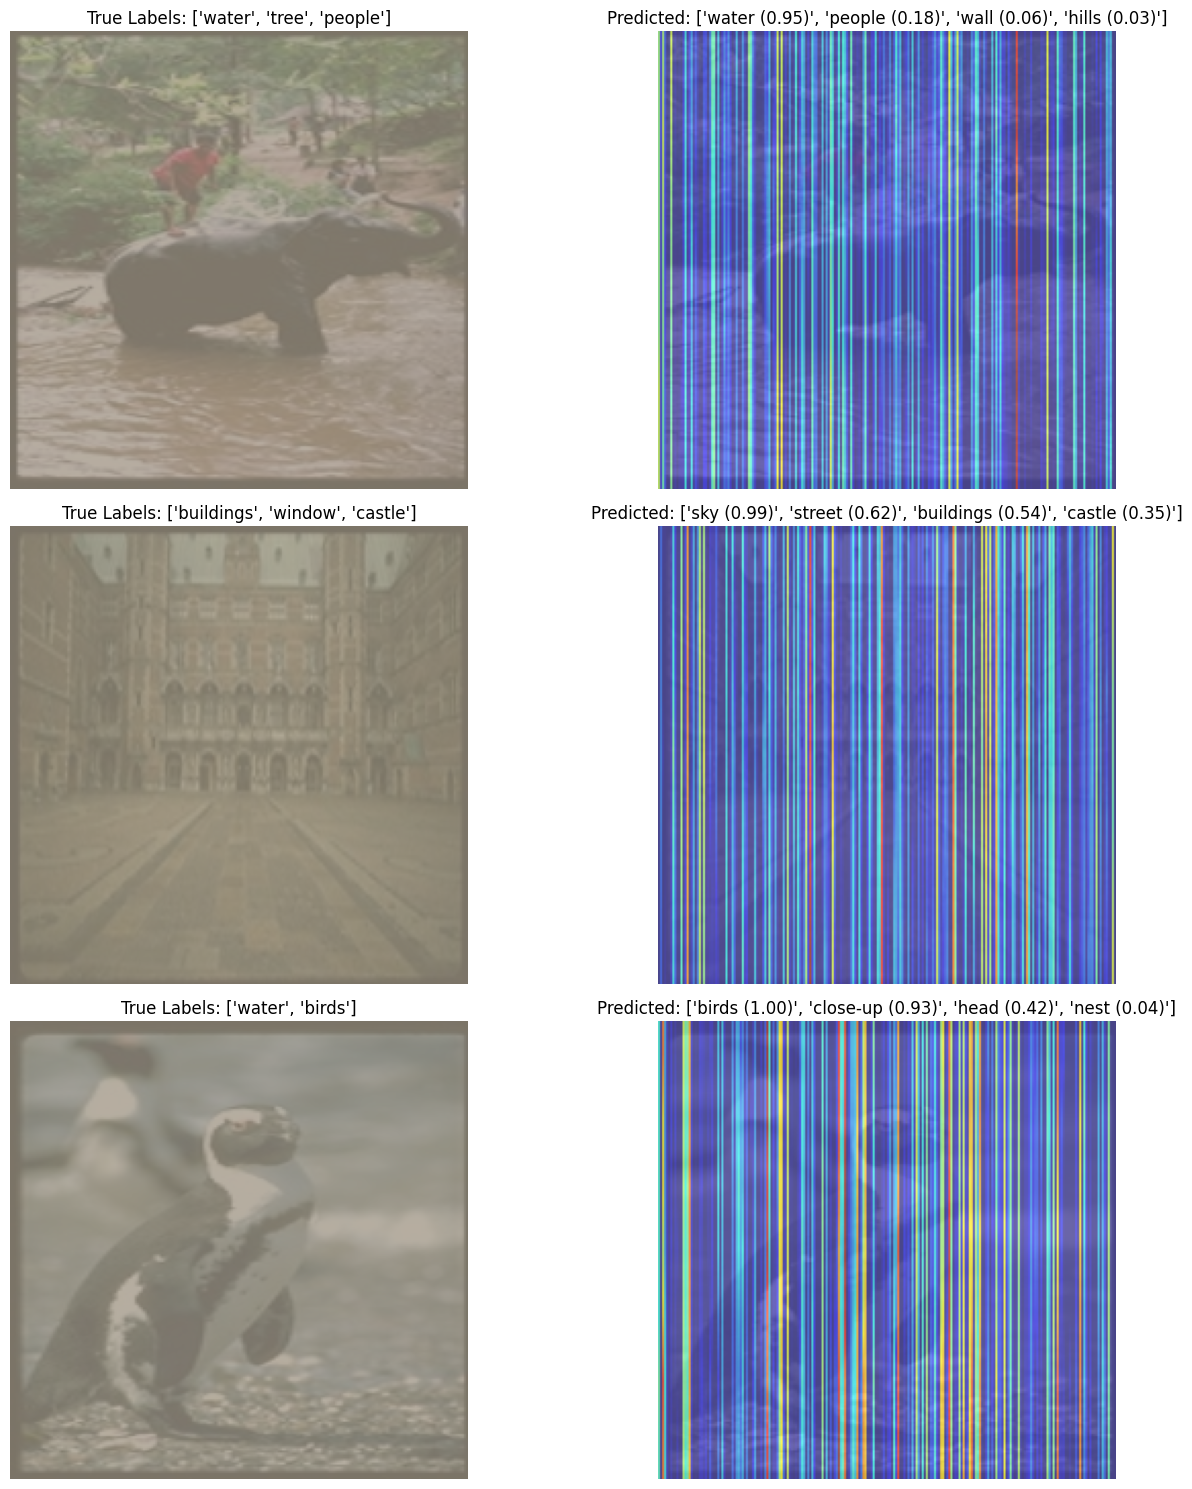

In [28]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
import torch

# Choose the last norm layer of Swin Transformer
target_layer = model.backbone.norm  # This is typically used for Swin
cam = GradCAM(model=model, target_layers=[target_layer], reshape_transform=None)

model.eval()
model.to(device)

num_to_show = 3
top_k = 4

test_samples = list(test_dataset)
random_samples = random.sample(test_samples, num_to_show)

plt.figure(figsize=(15, 5 * num_to_show))

for i, (image, true_labels) in enumerate(random_samples):
    # Image input
    input_tensor = image.unsqueeze(0).to(device)

    # Forward pass
    output = model(input_tensor)
    probs = torch.sigmoid(output).cpu().squeeze()

    # Top-k predictions
    topk_probs, topk_indices = torch.topk(probs, top_k)
    predicted_labels = [f"{label_columns[idx]} ({topk_probs[j]:.2f})" for j, idx in enumerate(topk_indices)]

    # GradCAM for the top-1 predicted class
    target_class = topk_indices[0].item()
    grayscale_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(target_class)])
    grayscale_cam = grayscale_cam[0, :]  # Remove batch dimension

    # Original image (unnormalized)
    inv_image = inv_normalize(image).permute(1, 2, 0).cpu().numpy()
    inv_image = np.clip(inv_image, 0, 1)

    # Show GradCAM overlay
    cam_image = show_cam_on_image(inv_image, grayscale_cam, use_rgb=True)

    plt.subplot(num_to_show, 2, 2 * i + 1)
    plt.imshow(inv_image)
    plt.axis("off")
    plt.title(f"True Labels: {[label_columns[j] for j in range(len(true_labels)) if true_labels[j] == 1]}")

    plt.subplot(num_to_show, 2, 2 * i + 2)
    plt.imshow(cam_image)
    plt.axis("off")
    plt.title(f"Predicted: {predicted_labels}")

plt.tight_layout()
plt.show()


In [21]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
import torch
import random

# Setup GradCAM
target_layer = model.backbone.norm  # For Swin Transformer
cam = GradCAM(model=model, target_layers=[target_layer], reshape_transform=None)

model.eval()
model.to(device)

num_to_show = 3
top_k = 3

# Sample test images
test_samples = list(test_dataset)
random_samples = random.sample(test_samples, num_to_show)

# Prepare display grid
fig, axs = plt.subplots(3, num_to_show, figsize=(5 * num_to_show, 10))

for i, (image, true_labels) in enumerate(random_samples):
    input_tensor = image.unsqueeze(0).to(device)

    # Forward pass
    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.sigmoid(output).cpu().squeeze()

    # Top-k predictions
    topk_probs, topk_indices = torch.topk(probs, top_k)
    predicted_labels = [f"{label_columns[idx]} ({topk_probs[j]:.2f})" for j, idx in enumerate(topk_indices)]

    # GradCAM for top-1 class
    target_class = topk_indices[0].item()
    grayscale_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(target_class)])
    grayscale_cam = grayscale_cam[0, :]  # Remove batch dimension

    # Original image (inverse normalize)
    inv_image = inv_normalize(image).permute(1, 2, 0).cpu().numpy()
    inv_image = np.clip(inv_image, 0, 1)

    # GradCAM overlay
    cam_image = show_cam_on_image(inv_image, grayscale_cam, use_rgb=True)

    # Ground truth labels
    true_label_names = [label_columns[j] for j in range(len(true_labels)) if true_labels[j] == 1]

    # Plot row 1: Ground Truth
    axs[0, i].imshow(inv_image)
    axs[0, i].axis("off")
    axs[0, i].set_title("True:\n" + "\n".join(true_label_names), fontsize=8)

    # Plot row 2: Predictions
    axs[1, i].imshow(inv_image)
    axs[1, i].axis("off")
    axs[1, i].set_title("Pred:\n" + "\n".join(predicted_labels), fontsize=8)

    # Plot row 3: Grad-CAM
    axs[2, i].imshow(cam_image)
    axs[2, i].axis("off")
    axs[2, i].set_title("Grad-CAM", fontsize=8)

plt.tight_layout()
plt.show()


ModuleNotFoundError: No module named 'pytorch_grad_cam'

In [17]:
# Load train and test sheets
xls_train = pd.ExcelFile(train_annotation_path)
df_train = pd.read_excel(xls_train, sheet_name='ImageID')
df_train_subset = df_train.iloc[:, 2:]

xls_test = pd.ExcelFile(test_annotation_path)
df_test = pd.read_excel(xls_test, sheet_name='Test')
df_test_subset = df_test.iloc[:, 2:]


NameError: name 'train_annotation_path' is not defined

# Filter and sort labels occurring more than once

In [16]:
# Calculate total label frequencies
total_label_count = df_train_subset.sum() + df_test_subset.sum()

# Filter and sort labels occurring more than once
filtered_label_counts = total_label_count[total_label_count > 1]
valid_labels = filtered_label_counts.sort_values(ascending=False).index.tolist()

print(f"Using {len(valid_labels)} valid labels (occurring >1 time)")

Using 347 valid labels (occurring >1 time)


In [18]:
# Keep only file_name and valid_labels
df_train = df_train[['file_name'] + valid_labels]
df_test = df_test[['file_name'] + valid_labels]

# Split train into train/validation
train_df = df_train.sample(frac=0.8, random_state=42)
valid_df = df_train.drop(train_df.index)

In [19]:
# -----------------------------
# Define Transformations
# -----------------------------
image_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])


In [17]:
##Sorting the labels
total_label_count = df_subset_sum + df1_subset_sum
sorted_total_label_count = total_label_count.sort_values(ascending = False)
print(sorted_total_label_count)
#calculating the number of labels
num_classes = total_label_count[total_label_count > 0].count()
print("Total unique labels:", num_classes)

water     1120
sky        988
tree       947
people     744
grass      497
          ... 
ladder       1
rapids       1
model        1
aerial       1
insect       1
Length: 374, dtype: int64
Total unique labels: 374


In [8]:
total_label_count = df_subset.sum() + df1_subset.sum()
filtered_label_counts = total_label_count[total_label_count > 1]
valid_labels = filtered_label_counts.index.tolist()
num_classes = len(valid_labels)
print(f"Using {num_classes} valid labels (occurring >1 time)")

Using 347 valid labels (occurring >1 time)


# Apply Filter based on the average labels occurrence

In [32]:
# 1. Compute total label counts for each
train_label_counts = df_train_subset.sum()
test_label_counts = df_test_subset.sum()

# 2. Compute average frequency in each
train_avg_freq = train_label_counts.mean()
test_avg_freq = test_label_counts.mean()

print(f"Train Avg Frequency: {train_avg_freq:.2f}")
print(f"Test Avg Frequency: {test_avg_freq:.2f}")

# 3. Filter labels in each set based on its own average
train_valid_labels = train_label_counts[train_label_counts > train_avg_freq].index.tolist()
test_valid_labels = test_label_counts[test_label_counts > test_avg_freq].index.tolist()

# 4. Combine label sets (choose strategy)
# Strategy A: Intersection (labels common to both)
common_valid_labels = list(set(train_valid_labels) & set(test_valid_labels))

# Strategy B: Union (labels valid in either set)
# all_valid_labels = list(set(train_valid_labels) | set(test_valid_labels))

print(f"Train valid labels: {len(train_valid_labels)}")
print(f"Test valid labels: {len(test_valid_labels)}")
print(f"Common valid labels (intersection): {len(common_valid_labels)}")


Train Avg Frequency: 42.37
Test Avg Frequency: 4.70
Train valid labels: 83
Test valid labels: 81
Common valid labels (intersection): 69


In [35]:
common_valid_labels = list(set(train_valid_labels) & set(test_valid_labels))
# Print all class names
print("Filtered Class Names (Labels > Avg Frequency in both sets):")
for label in sorted(common_valid_labels):
    print(label)

# Optional: save to file
with open("filtered_classes.txt", "w") as f:
    for label in sorted(common_valid_labels):
        f.write(f"{label}\n")



Filtered Class Names (Labels > Avg Frequency in both sets):
beach
bear
birds
boats
bridge
buildings
cars
castle
cat
city
close-up
clouds
coast
coral
desert
field
flowers
foals
forest
fox
frost
garden
grass
hills
horses
house
ice
jet
leaf
locomotive
mare
mountain
nest
ocean
people
pillar
plane
plants
polar
pool
railroad
reefs
reflection
rocks
ruins
sand
scotland
sculpture
shore
sky
skyline
smoke
snow
statue
stone
street
sun
sunset
swimmers
temple
tiger
town
tracks
train
tree
valley
wall
water
window


In [36]:
class MultiLabelImageDataset(Dataset):
    def __init__(self, dataframe, image_dir, valid_labels, transform=None):
        self.df = dataframe
        self.image_dir = image_dir
        self.valid_labels = valid_labels
        self.transform = transform
        self.label_indices = {label: idx for idx, label in enumerate(valid_labels)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = os.path.join(self.image_dir, row['file_name'])
        image = Image.open(image_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)

        label_vector = torch.zeros(len(self.valid_labels), dtype=torch.float32)
        for label in self.valid_labels:
            if label in row and row[label] == 1:
                label_vector[self.label_indices[label]] = 1.0

        return image, label_vector


In [37]:
# -----------------------------
# Create Dataset and DataLoader
# -----------------------------
train_dataset = MultiLabelImageDataset(train_df, base_image_folder, common_valid_labels, transform=image_transforms)
valid_dataset = MultiLabelImageDataset(valid_df, base_image_folder, common_valid_labels, transform=image_transforms)
test_dataset = MultiLabelImageDataset(df_test, base_image_folder, common_valid_labels, transform=image_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)


In [38]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.metrics import average_precision_score, f1_score
from tqdm import tqdm
import numpy as np
import timm
class SwinClassifier(nn.Module):
    def __init__(self, num_classes):
        super(SwinClassifier, self).__init__()
        self.backbone = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=0)
        self.classifier = nn.Linear(self.backbone.num_features, num_classes)

    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)



In [39]:
#device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model, Criterion, Optimizer
model = SwinClassifier(num_classes=len(common_valid_labels)).to(device)
criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [18]:
from tqdm import tqdm
import torch

num_epochs = 10  
threshold = 0.5  # for converting logits to binary predictions

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_labels = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)

    for images, labels in loop:
        images = images.to(device)
        labels = labels.to(device).float()

        optimizer.zero_grad()
        outputs = model(images)  # raw logits
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        # ---- Accuracy Calculation ----
        preds = torch.sigmoid(outputs)  # convert logits to probabilities
        preds = (preds > threshold).float()  # binary predictions

        correct = (preds == labels).float().sum()  # total correct labels
        total_correct += correct
        total_labels += torch.numel(labels)

        loop.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(train_loader)
    accuracy = total_correct / total_labels

    print(f"Epoch {epoch+1} - Avg Loss: {avg_loss:.4f} | Accuracy: {accuracy:.4f}")



Epoch 1 - Avg Loss: 0.1021 | Accuracy: 0.9695


Epoch 2 - Avg Loss: 0.0461 | Accuracy: 0.9899


Epoch 3 - Avg Loss: 0.0443 | Accuracy: 0.9899


Epoch 4 - Avg Loss: 0.0402 | Accuracy: 0.9901


Epoch 5 - Avg Loss: 0.0351 | Accuracy: 0.9908


Epoch 6 - Avg Loss: 0.0302 | Accuracy: 0.9917


Epoch 7 - Avg Loss: 0.0260 | Accuracy: 0.9926


Epoch 8 - Avg Loss: 0.0223 | Accuracy: 0.9934


Epoch 9 - Avg Loss: 0.0194 | Accuracy: 0.9942


Epoch 10 - Avg Loss: 0.0162 | Accuracy: 0.9950


In [40]:
# ============ Metric  ============

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
train_maps, val_maps = [], []
train_f1s, val_f1s = [], []
num_epochs = 10  

# ============ Training Loop ============
for epoch in range(num_epochs):
    model.train()
    total_loss, total_correct, total_samples = 0, 0, 0
    all_train_preds, all_train_labels = [], []

    for images, labels in tqdm(train_loader, desc=f"[Train] Epoch {epoch+1}/{num_epochs}"):
        images, labels = images.to(device), labels.to(device).float()

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = (outputs.sigmoid() > 0.5).float()
        total_correct += (preds == labels).sum().item()
        total_samples += labels.numel()

        all_train_preds.append(preds.cpu().numpy())
        all_train_labels.append(labels.cpu().numpy())

    # Compute Metrics
    avg_loss = total_loss / len(train_loader)
    acc = total_correct / total_samples
    train_preds = np.vstack(all_train_preds)
    train_labels = np.vstack(all_train_labels)
    train_map = average_precision_score(train_labels, train_preds, average='macro')
    train_f1 = f1_score(train_labels, train_preds, average='macro', zero_division=0)

    # Store Metrics
    train_losses.append(avg_loss)
    train_accuracies.append(acc)
    train_maps.append(train_map)
    train_f1s.append(train_f1)

    print(f"[Train] Epoch {epoch+1}: Loss={avg_loss:.4f} | Acc={acc:.4f} | mAP={train_map:.4f} | F1={train_f1:.4f}")

[Train] Epoch 1/10: 100%|██████████| 113/113 [00:29<00:00,  3.88it/s]


[Train] Epoch 1: Loss=0.1659 | Acc=0.9529 | mAP=0.0404 | F1=0.0265


[Train] Epoch 2/10: 100%|██████████| 113/113 [00:29<00:00,  3.88it/s]


[Train] Epoch 2: Loss=0.0988 | Acc=0.9679 | mAP=0.1498 | F1=0.2217


[Train] Epoch 3/10: 100%|██████████| 113/113 [00:29<00:00,  3.89it/s]


...

[Train] Epoch 8: Loss=0.0186 | Acc=0.9944 | mAP=0.8199 | F1=0.8938


[Train] Epoch 9/10: 100%|██████████| 113/113 [00:29<00:00,  3.89it/s]


[Train] Epoch 9: Loss=0.0140 | Acc=0.9962 | mAP=0.8856 | F1=0.9370


[Train] Epoch 10/10: 100%|██████████| 113/113 [00:29<00:00,  3.89it/s]


[Train] Epoch 10: Loss=0.0107 | Acc=0.9974 | mAP=0.9155 | F1=0.9543


In [41]:
# -------- Validation --------
model.eval()
val_loss = 0
val_correct = 0
val_samples = 0
all_val_preds = []
all_val_labels = []

with torch.no_grad():
    for images, labels in tqdm(valid_loader, desc=f"[Valid] Epoch {epoch+1}/{num_epochs}"):
        images = images.to(device)
        labels = labels.to(device).float()
        
        outputs = model(images)
        loss = criterion(outputs, labels)

        val_loss += loss.item()
        preds = (outputs.sigmoid() > 0.5).float()
        val_correct += (preds == labels).sum().item()
        val_samples += labels.numel()

        all_val_preds.append(preds.cpu().numpy())
        all_val_labels.append(labels.cpu().numpy())

val_preds = np.vstack(all_val_preds)
val_labels = np.vstack(all_val_labels)

val_acc = val_correct / val_samples
val_map = average_precision_score(val_labels, val_preds, average='macro')
val_f1 = f1_score(val_labels, val_preds, average='macro', zero_division=0)

val_losses.append(val_loss / len(valid_loader))
val_accuracies.append(val_acc)
val_maps.append(val_map)
val_f1s.append(val_f1)

print(f"[Valid] Loss: {val_loss / len(valid_loader):.4f} | Acc: {val_acc:.4f} | mAP: {val_map:.4f} | F1: {val_f1:.4f}")


[Valid] Epoch 10/10: 100%|██████████| 29/29 [00:04<00:00,  6.31it/s]

[Valid] Loss: 0.0739 | Acc: 0.9785 | mAP: 0.4654 | F1: 0.5999


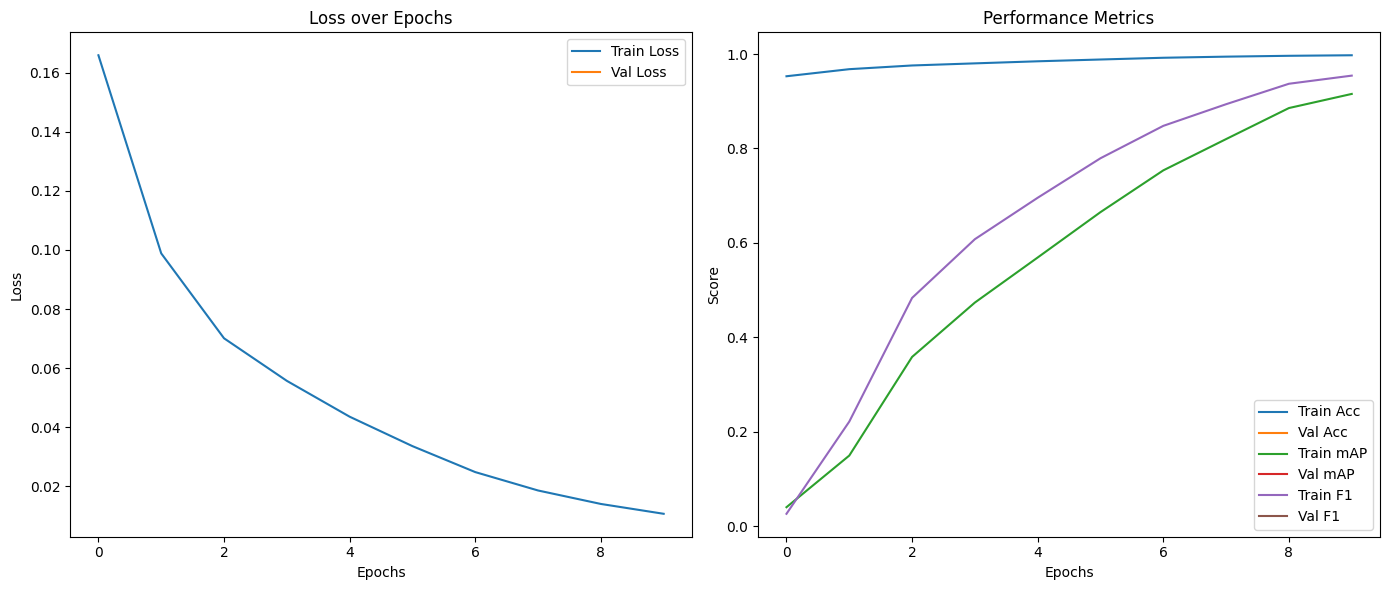

In [42]:
# ============ Plotting ============
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss over Epochs")

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Acc')
plt.plot(val_accuracies, label='Val Acc')
plt.plot(train_maps, label='Train mAP')
plt.plot(val_maps, label='Val mAP')
plt.plot(train_f1s, label='Train F1')
plt.plot(val_f1s, label='Val F1')
plt.xlabel("Epochs")
plt.ylabel("Score")
plt.legend()
plt.title("Performance Metrics")
plt.tight_layout()
plt.show()


In [43]:
# -------- Testing --------
model.eval()
test_loss = 0
test_correct = 0
test_samples = 0
all_test_preds = []
all_test_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="[Test]"):
        images = images.to(device)
        labels = labels.to(device).float()

        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item()
        preds = (outputs.sigmoid() > 0.5).float()
        test_correct += (preds == labels).sum().item()
        test_samples += labels.numel()

        all_test_preds.append(preds.cpu().numpy())
        all_test_labels.append(labels.cpu().numpy())

test_preds = np.vstack(all_test_preds)
test_labels = np.vstack(all_test_labels)

test_acc = test_correct / test_samples
test_map = average_precision_score(test_labels, test_preds, average='macro')
test_f1 = f1_score(test_labels, test_preds, average='macro', zero_division=0)

print(f"[Test] Loss: {test_loss / len(test_loader):.4f} | Acc: {test_acc:.4f} | mAP: {test_map:.4f} | F1: {test_f1:.4f}")


[Test]: 100%|██████████| 16/16 [00:02<00:00,  5.92it/s]

[Test] Loss: 0.0753 | Acc: 0.9775 | mAP: 0.4793 | F1: 0.6174


# Plot for Loss, Accuracy,maP, 

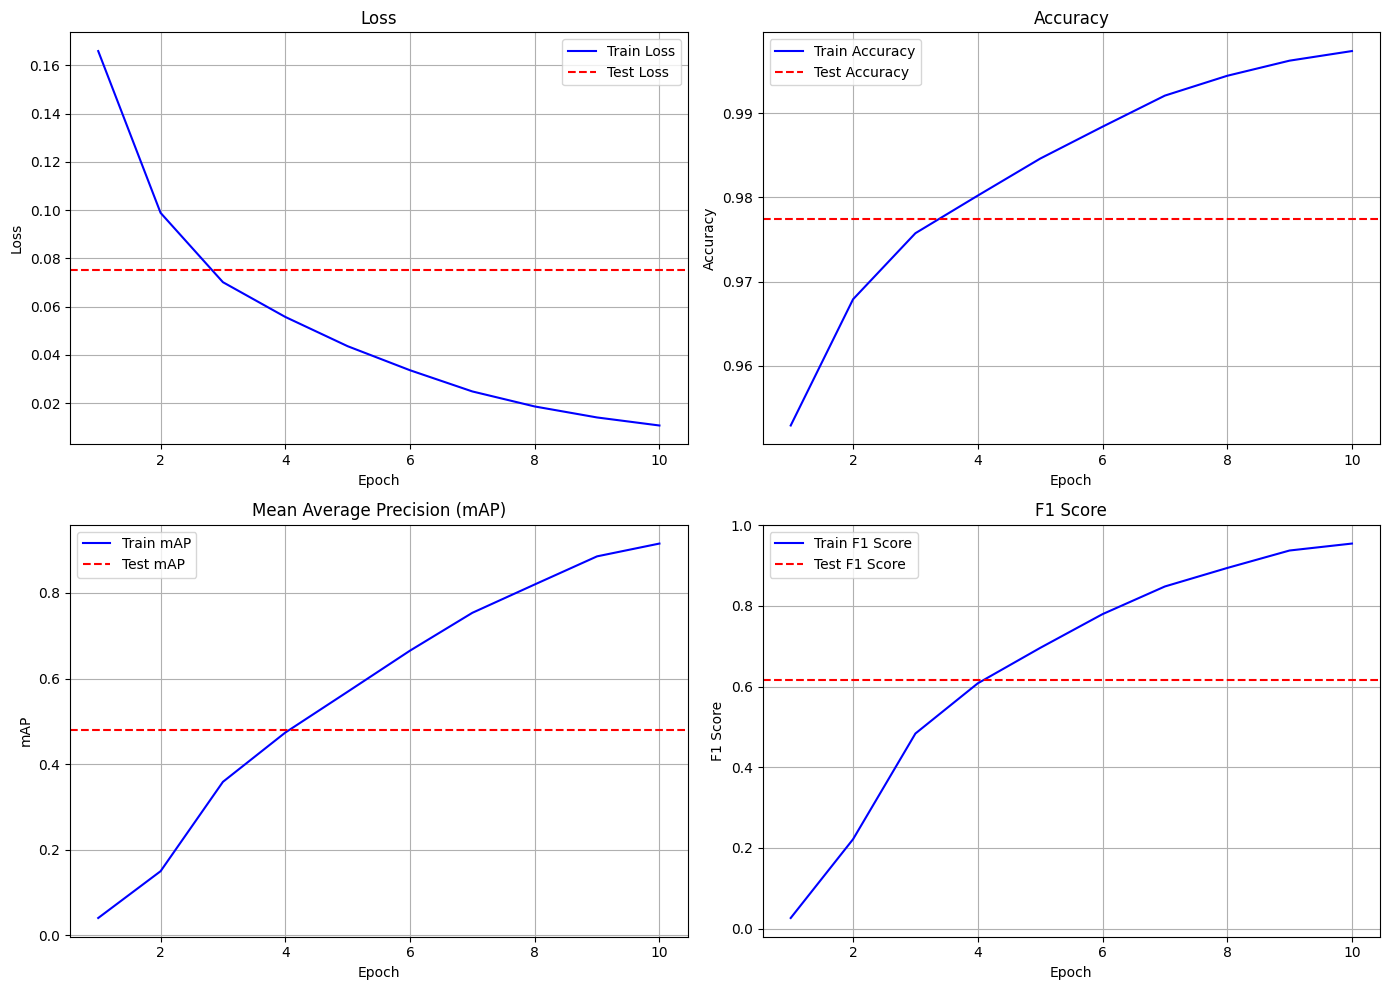

In [44]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(train_losses) + 1))

plt.figure(figsize=(14, 10))

# -------- Loss --------
plt.subplot(2, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss', color='blue')
plt.axhline(y=test_loss / len(test_loader), color='red', linestyle='--', label='Test Loss')
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# -------- Accuracy --------
plt.subplot(2, 2, 2)
plt.plot(epochs, train_accuracies, label='Train Accuracy', color='blue')
plt.axhline(y=test_acc, color='red', linestyle='--', label='Test Accuracy')
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# -------- mAP --------
plt.subplot(2, 2, 3)
plt.plot(epochs, train_maps, label='Train mAP', color='blue')
plt.axhline(y=test_map, color='red', linestyle='--', label='Test mAP')
plt.title("Mean Average Precision (mAP)")
plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.legend()
plt.grid(True)

# -------- F1 Score --------
plt.subplot(2, 2, 4)
plt.plot(epochs, train_f1s, label='Train F1 Score', color='blue')
plt.axhline(y=test_f1, color='red', linestyle='--', label='Test F1 Score')
plt.title("F1 Score")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# Sample Test Images

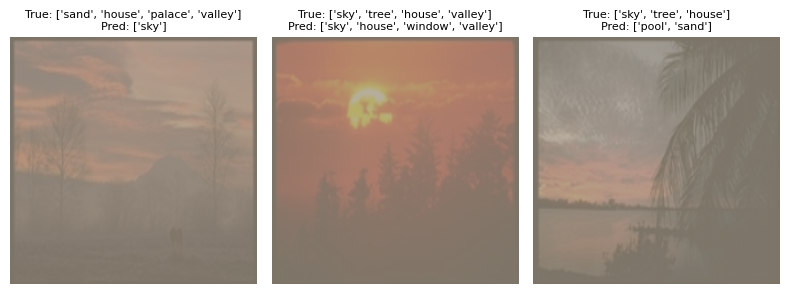

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# Inverse transform for normalization (if you used ImageNet means and stds)
inv_normalize = transforms.Normalize(
    mean=[-m/s for m, s in zip([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])],
    std=[1/s for s in [0.229, 0.224, 0.225]]
)

# Class index to name mapping (assuming valid_labels is used for indexing)
idx_to_label = {i: label for i, label in enumerate(valid_labels)}

# Pick a few test images
model.eval()
num_images_to_show = 3
shown = 0

plt.figure(figsize=(8, 10))

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device).float()
        outputs = model(images)
        preds = (outputs.sigmoid() > 0.5).float()

        for i in range(images.size(0)):
            if shown >= num_images_to_show:
                break

            # Inverse normalize and convert to numpy
            img = inv_normalize(images[i].cpu())
            img = img.permute(1, 2, 0).numpy()
            img = np.clip(img, 0, 1)

            true_lbls = [idx_to_label[j] for j in range(len(labels[i])) if labels[i][j] == 1]
            pred_lbls = [idx_to_label[j] for j in range(len(preds[i])) if preds[i][j] == 1]

            plt.subplot(2, 3, shown + 1)
            plt.imshow(img)
            plt.axis('off')
            plt.title(f"True: {true_lbls}\nPred: {pred_lbls}", fontsize=8)

            shown += 1

        if shown >= num_images_to_show:
            break

plt.tight_layout()
plt.show()


# Sample Test images with probabiliy scores

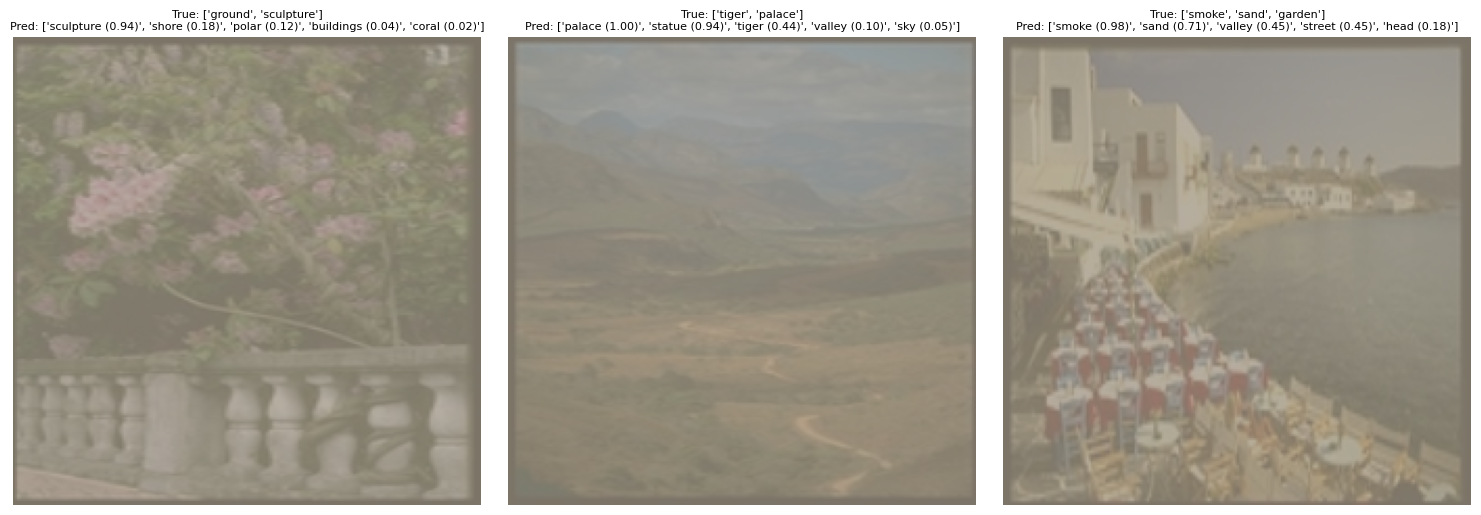

In [46]:
import random
import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision import transforms

# Inverse normalization (ImageNet stats)
inv_normalize = transforms.Normalize(
    mean=[-m/s for m, s in zip([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])],
    std=[1/s for s in [0.229, 0.224, 0.225]]
)

# Mapping from index to label
idx_to_label = {i: label for i, label in enumerate(valid_labels)}

# Convert full test dataset to a list
test_samples = list(test_dataset)
num_to_show = 3
top_k = 5

# Randomly select N samples
random_samples = random.sample(test_samples, num_to_show)

plt.figure(figsize=(15, 10))
model.eval()

for i, (image, true_labels) in enumerate(random_samples):
    # Prepare image
    image_input = image.unsqueeze(0).to(device)
    true_labels = true_labels.numpy()

    with torch.no_grad():
        outputs = model(image_input)
        probs = outputs.sigmoid().cpu().squeeze()

    # Get top-k predicted labels and scores
    topk_probs, topk_indices = torch.topk(probs, top_k)
    ranked_preds = [f"{idx_to_label[idx.item()]} ({topk_probs[j].item():.2f})"
                    for j, idx in enumerate(topk_indices)]

    # Get ground truth label names
    true_lbls = [idx_to_label[i] for i in range(len(true_labels)) if true_labels[i] == 1]

    # Convert image to display format
    img_disp = inv_normalize(image).permute(1, 2, 0).numpy()
    img_disp = np.clip(img_disp, 0, 1)

    # Plot
    plt.subplot(2, 3, i + 1)
    plt.imshow(img_disp)
    plt.axis('off')
    plt.title(f"True: {true_lbls}\nPred: {ranked_preds}", fontsize=8)

plt.tight_layout()
plt.show()


# Classification Report

In [39]:
from sklearn.metrics import classification_report

# Classification report
report = classification_report(
    test_labels,
    (test_preds > 0.5).astype(int),
    target_names=valid_labels,
    zero_division=0
)

print("Classification Report:\n")
print(report)


Classification Report:

                precision    recall  f1-score   support

          city       1.00      0.20      0.33        10
      mountain       0.87      0.53      0.66        38
           sky       0.69      0.56      0.62       105
           sun       0.70      0.70      0.70        10
         water       0.87      0.75      0.81       116
        clouds       0.64      0.35      0.45        26
          tree       0.70      0.60      0.65        93
           bay       0.00      0.00      0.00         0
          lake       0.00      0.00      0.00         1
           sea       0.00      0.00      0.00         2
         beach       0.90      0.50      0.64        18
         boats       0.67      0.27      0.38        15
        people       0.78      0.85      0.81        74
        branch       0.50      0.50      0.50         2
          leaf       0.82      0.75      0.78        12
         grass       0.64      0.53      0.58        51
         plain       0.

# Overall model mAP

In [42]:
import numpy as np
from sklearn.metrics import average_precision_score

# Make sure both are NumPy arrays on CPU
labels_np = labels.cpu().numpy()
preds_np = preds.cpu().numpy()

# Now compute mAP safely
map_macro = average_precision_score(labels_np, preds_np, average='macro')
map_micro = average_precision_score(labels_np, preds_np, average='micro')

print(f"mAP (macro): {map_macro:.4f}")
print(f"mAP (micro): {map_micro:.4f}")


mAP (macro): 0.0409
mAP (micro): 0.4865


/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:891: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:891: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:891: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:891: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:891: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:891: UserWarning: No positive class f

# Finding  Per-Class Average Precision (AP) scores,

In [47]:
from sklearn.metrics import average_precision_score
import numpy as np

# Convert tensors to numpy if they are torch tensors
if hasattr(test_preds, 'cpu'):
    test_preds = test_preds.cpu().numpy()
if hasattr(test_labels, 'cpu'):
    test_labels = test_labels.cpu().numpy()

# Calculate AP per class
per_class_ap = average_precision_score(test_labels, test_preds, average=None)

# Sort by AP
sorted_indices = np.argsort(per_class_ap)
sorted_ap = per_class_ap[sorted_indices]

# If you have class names, use them; otherwise, use class indices
sorted_class_names = [valid_labels[i] if i < len(valid_labels) else f"Class_{i}" for i in sorted_indices]

# Print per-class AP
print("Per-Class Average Precision Scores (Sorted):")
for cls, ap in zip(sorted_class_names, sorted_ap):
    print(f"{cls}: {ap:.4f}")


Per-Class Average Precision Scores (Sorted):
chapel: -0.0000
moon: -0.0000
sponges: -0.0000
parade: -0.0000
steps: -0.0000
fog: -0.0000
spider: -0.0000
pebbles: -0.0000
bay: -0.0000
tomb: -0.0000
steel: -0.0000
fall: -0.0000
stream: -0.0000
drum: -0.0000
dall: -0.0000
rabbit: -0.0000
wolf: -0.0000
pack: -0.0000
seals: -0.0000
texture: -0.0000
dust: -0.0000
eagle: -0.0000
straightaway: -0.0000
plain: -0.0000
shell: -0.0000
dog: -0.0000
storm: -0.0000
stick: -0.0000
pottery: -0.0000
designs: -0.0000
tent: -0.0000
angelfish: -0.0000
pagoda: -0.0000
writing: -0.0000
giant: -0.0000
tortoise: -0.0000
wings: -0.0000
penguin: -0.0000
paintings: -0.0000
mural: -0.0000
star: -0.0000
crowd: -0.0000
shrine: -0.0000
carpet: -0.0000
floor: -0.0000
poppies: -0.0000
fawn: -0.0000
clearing: -0.0000
rainbow: -0.0000
carvings: -0.0000
sailboats: -0.0000
run: -0.0000
winter: -0.0000
autumn: -0.0000
cliff: -0.0000
room: -0.0000
perch: -0.0000
figures: -0.0000
facade: -0.0000
chairs: -0.0000
guard: -0.0000


/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:891: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:891: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:891: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:891: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:891: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:891: UserWarning: No positive class f

# Threshold Tuning Per Label

In [50]:
import torch
import numpy as np
from sklearn.metrics import f1_score, classification_report

import numpy as np
from sklearn.metrics import average_precision_score, f1_score

# val_preds: raw sigmoid outputs (probabilities)
# val_labels: ground truth (0 or 1)
# test_preds: raw sigmoid outputs (probabilities)
# test_labels: ground truth (0 or 1)

num_classes = val_labels.shape[1]
thresholds = np.zeros(num_classes)

# Find optimal threshold for each class on the validation set
for i in range(num_classes):
    best_f1 = 0
    best_thresh = 0.5
    for t in np.linspace(0.05, 0.95, 19):
        pred_bin = (val_preds[:, i] > t).astype(int)
        f1 = f1_score(val_labels[:, i], pred_bin, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = t
    thresholds[i] = best_thresh

print("Optimal thresholds per class:\n", thresholds)


Classification Report with Tuned Thresholds:

                precision    recall  f1-score   support

          city       0.40      0.40      0.40        10
      mountain       0.81      0.66      0.72        38
           sky       0.58      0.72      0.64       105
           sun       0.45      0.90      0.60        10
         water       0.84      0.78      0.81       116
        clouds       0.44      0.58      0.50        26
          tree       0.58      0.72      0.64        93
           bay       0.00      0.00      0.00         0
          lake       0.00      0.00      0.00         1
           sea       0.00      0.00      0.00         2
         beach       0.69      0.61      0.65        18
         boats       0.50      0.40      0.44        15
        people       0.75      0.91      0.82        74
        branch       0.09      0.50      0.15         2
          leaf       0.82      0.75      0.78        12
         grass       0.48      0.76      0.59        51
 

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
